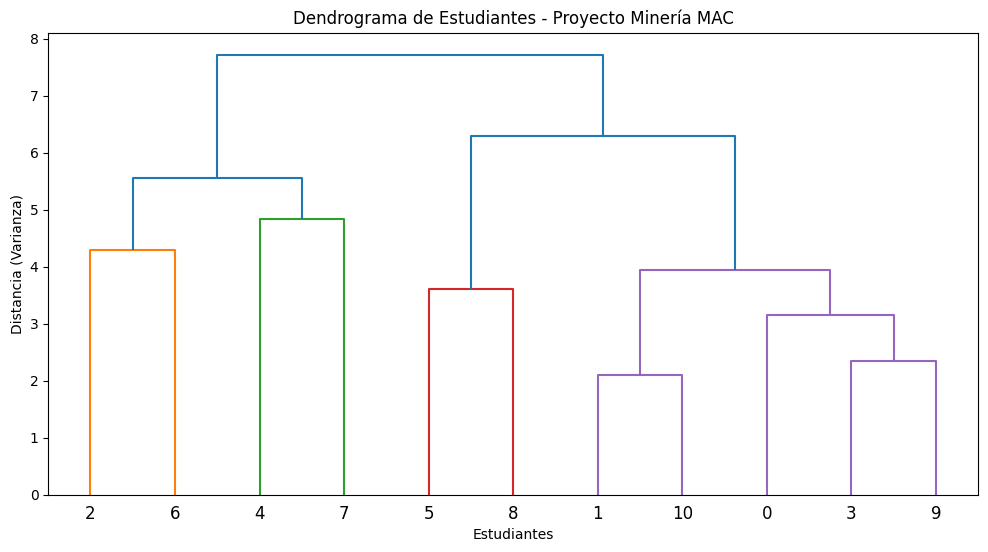

¡Listo! Se procesaron 11 estudiantes.
   cluster_social  habilidadSocial  amigos  enfoque  noviazgo  tiempoSoltero  \
0               1                2       1        1         1            0.0   
1               1                3       1        0         1            2.0   
3               0                4       0        0         0            2.0   
4               1                3       1        1         0            1.0   
6               0                1       0        0         0            3.0   

   participacion  comunicacion  colaborativo  integracion  \
0              0             1             1          5.0   
1              1             1             1          4.0   
3              2             1             1          2.0   
4              0             1             1          4.0   
6              0             1             0          4.0   

   energiaInterpersonal  
0                     4  
1                     3  
3                     5  
4         

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder

#  ARCHIVO
df = pd.read_csv('../documents/data/clean/RelacionesPersonales(limpio).csv')


# (Label Encoding para las columnas de texto)
# Cconvertir las respuestas de texto:
le = LabelEncoder()
columnas_texto = ['confianzaInterpersonal', 'tiempoLibre', 'iniciativaInteraccion']

for col in columnas_texto:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# 3. SELECCIÓN DE VARIABLES

columnas_estudio = [
    'habilidadSocial', 'amigos', 'enfoque', 'noviazgo',
    'tiempoSoltero', 'participacion', 'comunicacion',
    'colaborativo', 'integracion', 'energiaInterpersonal'
]
X = df[columnas_estudio]

# . ESCALAMIENTO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Seleccionas tus columnas
X = df[columnas_estudio]

# ELIMINAR NULOS
X = X.dropna()

# Todo flotante por si acaso
X = X.astype(float)

#Escalas y graficas
X_scaled = scaler.fit_transform(X)

# DENDROGRAMA (Método Ward)
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrograma de Estudiantes - Proyecto Minería MAC')
plt.xlabel('Estudiantes')
plt.ylabel('Distancia (Varianza)')
plt.show()


# APLICAR CLUSTERING
n_clusters = 3
modelo = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')

# Copia del dataframe original que solo tenga las filas que NO tienen nulos
df_limpio = df.dropna(subset=columnas_estudio).copy()

# Asignamos los clusters a esa copia
df_limpio['cluster_social'] = modelo.fit_predict(X_scaled)

# GUARDAR RESULTADOS
df_limpio.to_csv('resultados_tarea_clustering.csv', index=False)

print(f"¡Listo! Se procesaron {len(df_limpio)} estudiantes.")
print(df_limpio[['cluster_social'] + columnas_estudio].head())